In [ ]:
import  numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt

from datetime import datetime


In [ ]:
#Question No.1
# What is the day for the date, September 11, 1952
# Use .strftime('%A') to identify the day (e.g. Monday, Tuesday)

day_forthe_date= datetime(1952,9,11)
day_forthe_date.strftime('%A')


'Thursday'

In [ ]:
#Question No. 2
#Using pd.date_range, create dates starting from October 15, 2008 with 85 periods with day frequency.
#What date is second to the last?

range = pd.date_range('10/15/2008', periods=85, freq='D')
range


DatetimeIndex(['2008-10-15', '2008-10-16', '2008-10-17', '2008-10-18',
               '2008-10-19', '2008-10-20', '2008-10-21', '2008-10-22',
               '2008-10-23', '2008-10-24', '2008-10-25', '2008-10-26',
               '2008-10-27', '2008-10-28', '2008-10-29', '2008-10-30',
               '2008-10-31', '2008-11-01', '2008-11-02', '2008-11-03',
               '2008-11-04', '2008-11-05', '2008-11-06', '2008-11-07',
               '2008-11-08', '2008-11-09', '2008-11-10', '2008-11-11',
               '2008-11-12', '2008-11-13', '2008-11-14', '2008-11-15',
               '2008-11-16', '2008-11-17', '2008-11-18', '2008-11-19',
               '2008-11-20', '2008-11-21', '2008-11-22', '2008-11-23',
               '2008-11-24', '2008-11-25', '2008-11-26', '2008-11-27',
               '2008-11-28', '2008-11-29', '2008-11-30', '2008-12-01',
               '2008-12-02', '2008-12-03', '2008-12-04', '2008-12-05',
               '2008-12-06', '2008-12-07', '2008-12-08', '2008-12-09',
      

In [ ]:
# Load Dataset (starbucks)
df_starbs=pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/starbucks.csv')
df_starbs

,Date,Close,Volume
0,2015-01-02,38.0061,6906098
1,2015-01-05,37.2781,11623796
2,2015-01-06,36.9748,7664340
3,2015-01-07,37.8848,9732554
4,2015-01-08,38.4961,13170548
...,...,...,...
1001,2018-12-24,60.5600,6323252
1002,2018-12-26,63.0800,16646238
1003,2018-12-27,63.2000,11308081
1004,2018-12-28,63.3900,7712127


In [ ]:
#Question No. 3
#Use the starbucks.csv dataset.
# If you resample the 'Close' column to weekly mean frequency, What is he value of 2016-05-01?

df_starbs['Date'] = pd.to_datetime(df_starbs['Date'])
df_starbs.set_index('Date', inplace=True)
weekly_mean = df_starbs['Close'].resample('W').mean()
value_2016_05_01 = weekly_mean['2016-05-01']
value_2016_05_01

54.0705

In [ ]:
#Question No. 4
#Use the starbucks.csv dataset.
# If you resample the 'Close' column to quarter end median frequency, What is he value of 2017-12-31?


quarter_end_median = df_starbs['Close'].resample('QE').median()
value_2017_12_31 = quarter_end_median['2017-12-31']
value_2017_12_31

55.4539

In [ ]:
#5
#Use the Starbucks.csv dataset.
#If you resample the 'Volume' Column to semi-month end mean frequency, what is the median value of the last five dates?

semi_month_end_mean = df_starbs['Volume'].resample('SME').mean()
median_value = semi_month_end_mean.tail(5).median()
median_value

13981797.777777778

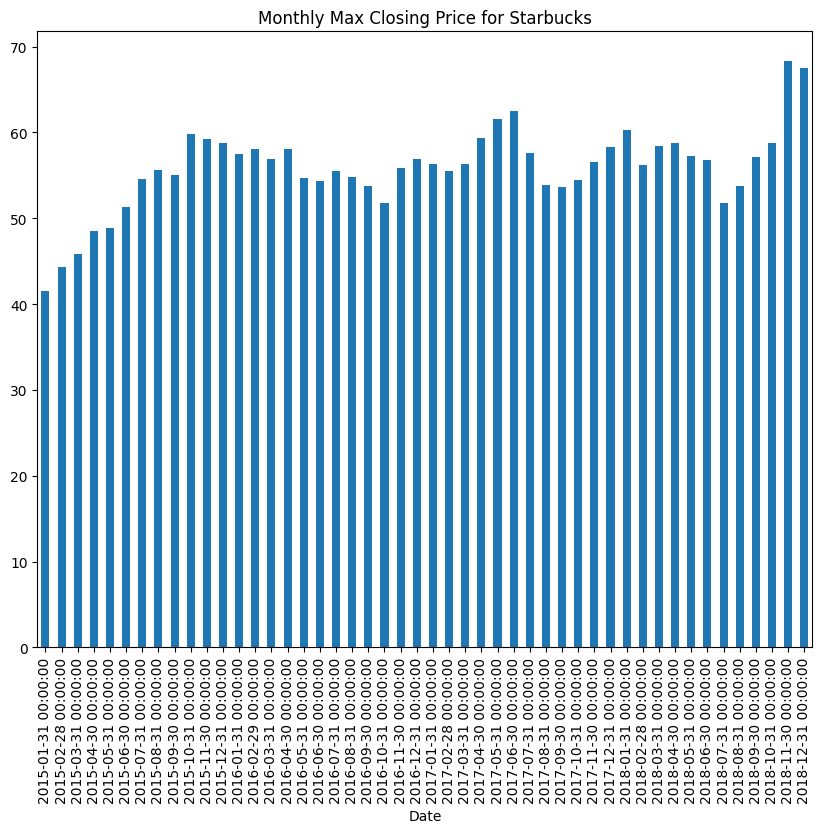

In [ ]:
#6
#Create a bar graph (vertical), show the maximum 'Close' price per month


monthly_max = df_starbs['Close'].resample('ME').max()

# Create the bar graph using the plot function with kind='bar'
monthly_max.plot.bar(figsize=(10, 8))

# Customize the graph
plt.title('Monthly Max Closing Price for Starbucks')
plt.xlabel('Date')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# Display the graph
plt.show()

In [ ]:
#7
#If I shift forward the starbucks data by a value of 17, what is the new value of 'Close' price for 2015-02-26?

shifted_data = df_starbs.shift(periods=17)
value_2015_02_26 = shifted_data.loc['2015-02-26', 'Close']
value_2015_02_26

41.0629

In [ ]:
#8
#If I shift backwards the starbukcs by a value of 28 , what is the new value of 'Close' price of 2018-08-31

shifted_data1 = df_starbs.shift(periods=-28)
value_2018_08_31 = shifted_data1.loc['2018-08-31', 'Close']
value_2018_08_31

54.567

In [ ]:
#9
#Using moving average (rolling) with 14 days window, find the closing price at 2015-04-09

rolling_mean = df_starbs['Close'].rolling(window=14).mean()
closing_price_2015_04_09 = rolling_mean.loc['2015-04-09']
closing_price_2015_04_09

44.71339285714286

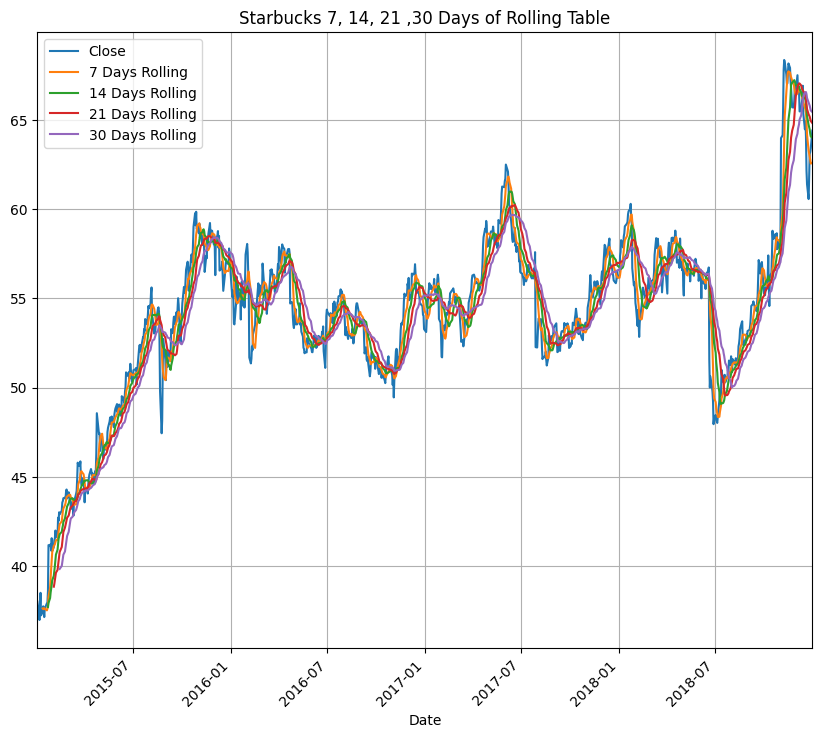

In [ ]:
#10
#Create the graph below with different rolling windows of 7, 14, 21 ,30

# Calculate rolling means for different windows
df_starbs['Close_7'] = df_starbs['Close'].rolling(window=7).mean()
df_starbs['Close_14'] = df_starbs['Close'].rolling(window=14).mean()
df_starbs['Close_21'] = df_starbs['Close'].rolling(window=21).mean()
df_starbs['Close_30'] = df_starbs['Close'].rolling(window=30).mean()

# Plot the rolling means along with the original 'Close' price
fig, ax = plt.subplots(figsize=(10, 8)) # Create figure and axes
ax.plot(df_starbs['Close'], label='Close')
ax.plot(df_starbs['Close_7'], label='7 Days Rolling')
ax.plot(df_starbs['Close_14'], label='14 Days Rolling')
ax.plot(df_starbs['Close_21'], label='21 Days Rolling')
ax.plot(df_starbs['Close_30'], label='30 Days Rolling')

# Autoscale the axes
ax.autoscale(axis='x', tight=True)

# Customize the plot
ax.set_title('Starbucks 7, 14, 21 ,30 Days of Rolling Table')
ax.set_xlabel('Date')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(True)

# Display the plot
plt.show()